<a href="https://colab.research.google.com/github/HM-Mahibullah/ComputerVision/blob/main/object_detection_with_face_name.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Video link : https://www.youtube.com/watch?v=0Z5ItCoIXXc

playlist link : https://drive.google.com/drive/folders/1t8yUSrIEyGndS44z9iPWwLM-s06kMMow

In [1]:
# ১. গুগল ড্রাইভ মাউন্ট করা
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 516.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 6.4 MB/s eta 0:00:00


In [3]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 20.3/107.7 GB disk)


In [ ]:
!pip install roboflow

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="mXMpr53fhzdntdGh4y4x")
project = rf.workspace("shafiullahs-workspace-ewajq").project("celebrity-faces-dataset-vd1h9")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Celebrity-Faces-Dataset-1 in yolov8:: 100%|██████████| 3429/3429 [00:00<00:00, 6284.88it/s]


In [2]:
print(dataset.location)

/content/Celebrity-Faces-Dataset-1


In [3]:
!pwd

/content


In [4]:
import albumentations as A
import cv2
import os

# ১. অগমেন্টেশনের রুলস সেট করুন
transform = A.Compose([
    A.HorizontalFlip(p=0.5),                # ৫০% সম্ভাবনা ছবি উল্টে যাওয়ার
    A.RandomBrightnessContrast(p=0.5),       # ব্রাইটনেস ও কনট্রাস্ট পরিবর্তন
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.5), # অল্প ঘোরানো বা জুম করা
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels'])) # YOLO format

# ২. আপনার আসল ছবি লোড করুন
image_path = "/content/mahibullah.jpg"
image = cv2.imread(image_path)

# বাউন্ডিং বক্স কোঅর্ডিনেট
bboxes = [[0.4557291666666667, 0.2259140625, 0.5677083333333334, 0.38671875]]
class_labels = [8]

# 🔴 আলাদা ফোল্ডার তৈরির পাথ ডিফাইন করা
IMAGE_FOLDER = "/content/dataset/images"
LABEL_FOLDER = "/content/dataset/labels"

# ফোল্ডারগুলো আগে থেকে না থাকলে স্বয়ংক্রিয়ভাবে তৈরি করে নেবে
os.makedirs(IMAGE_FOLDER, exist_ok=True)
os.makedirs(LABEL_FOLDER, exist_ok=True)

# জেনারেট করার টার্গেট সংখ্যা
TOTAL_IMAGES = 50

print("⏳ আলাদা ফোল্ডারে অগমেন্টেশন ফাইল সেভ হওয়া শুরু হচ্ছে...")

# ৩. লুপ চালিয়ে ৫০টি ইমেজ এবং লেবেল আলাদা ফোল্ডারে সেভ করা
for i in range(1, TOTAL_IMAGES + 1):
    transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)
    transformed_image = transformed['image']
    transformed_bboxes = transformed['bboxes']

    if len(transformed_bboxes) == 0:
        continue

    # 🔴 ফাইলের ডাইনামিক পাথ (আলাদা আলাদা ফোল্ডারে সেট করা হয়েছে)
    output_image_path = os.path.join(IMAGE_FOLDER, f"aug_{i}.jpg")
    output_label_path = os.path.join(LABEL_FOLDER, f"aug_{i}.txt")

    # ছবি সেভ করা (images ফোল্ডারে)
    cv2.imwrite(output_image_path, transformed_image)

    # YOLO লেবেল (.txt) ফাইল সেভ করা (labels ফোল্ডারে)
    with open(output_label_path, "w") as f:
        for idx, bbox in enumerate(transformed_bboxes):
            f.write(f"{class_labels[idx]} {bbox[0]:.6f} {bbox[1]:.6f} {bbox[2]:.6f} {bbox[3]:.6f}\n")

print(f"✅ সফল! সব ফাইল আলাদা হয়ে গেছে।\n📁 ছবিগুলো আছে: {IMAGE_FOLDER}\n📁 লেবেলগুলো আছে: {LABEL_FOLDER}")

ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.


⏳ আলাদা ফোল্ডারে অগমেন্টেশন ফাইল সেভ হওয়া শুরু হচ্ছে...
✅ সফল! সব ফাইল আলাদা হয়ে গেছে।
📁 ছবিগুলো আছে: /content/dataset/images
📁 লেবেলগুলো আছে: /content/dataset/labels


In [5]:
import os
import shutil

# ১. সোর্স পাথ (যেখান থেকে ফাইল নেওয়া হবে)
aug_images_dir = "/content/dataset/images"
aug_labels_dir = "/content/dataset/labels"

# ২. ডেস্টিনেশন পাথ (মেইন ডেটাসেটের train ফোল্ডার)
main_train_images_dir = "/content/Celebrity-Faces-Dataset-1/train/images"
main_train_labels_dir = "/content/Celebrity-Faces-Dataset-1/train/labels"

# ৩. ছবিগুলো মুভ করার লুপ
print("⏳ ছবিগুলো মেইন ডেটাসেটের train/images-এ মুভ হচ্ছে...")
for file_name in os.listdir(aug_images_dir):
    source = os.path.join(aug_images_dir, file_name)
    destination = os.path.join(main_train_images_dir, file_name)
    shutil.move(source, destination) # ফাইল মুভ করা হচ্ছে

# ৪. লেবেল ফাইলগুলো মুভ করার লুপ
print("⏳ লেবেলগুলো মেইন ডেটাসেটের train/labels-এ মুভ হচ্ছে...")
for file_name in os.listdir(aug_labels_dir):
    source = os.path.join(aug_labels_dir, file_name)
    destination = os.path.join(main_train_labels_dir, file_name)
    shutil.move(source, destination)

print("✅ সফলভাবে সব অগমেন্টেড ছবি এবং লেবেল মেইন 'train' ফোল্ডারে মুভ করা হয়েছে!")

⏳ ছবিগুলো মেইন ডেটাসেটের train/images-এ মুভ হচ্ছে...
⏳ লেবেলগুলো মেইন ডেটাসেটের train/labels-এ মুভ হচ্ছে...
✅ সফলভাবে সব অগমেন্টেড ছবি এবং লেবেল মেইন 'train' ফোল্ডারে মুভ করা হয়েছে!


In [6]:
!rm -rf dataset/

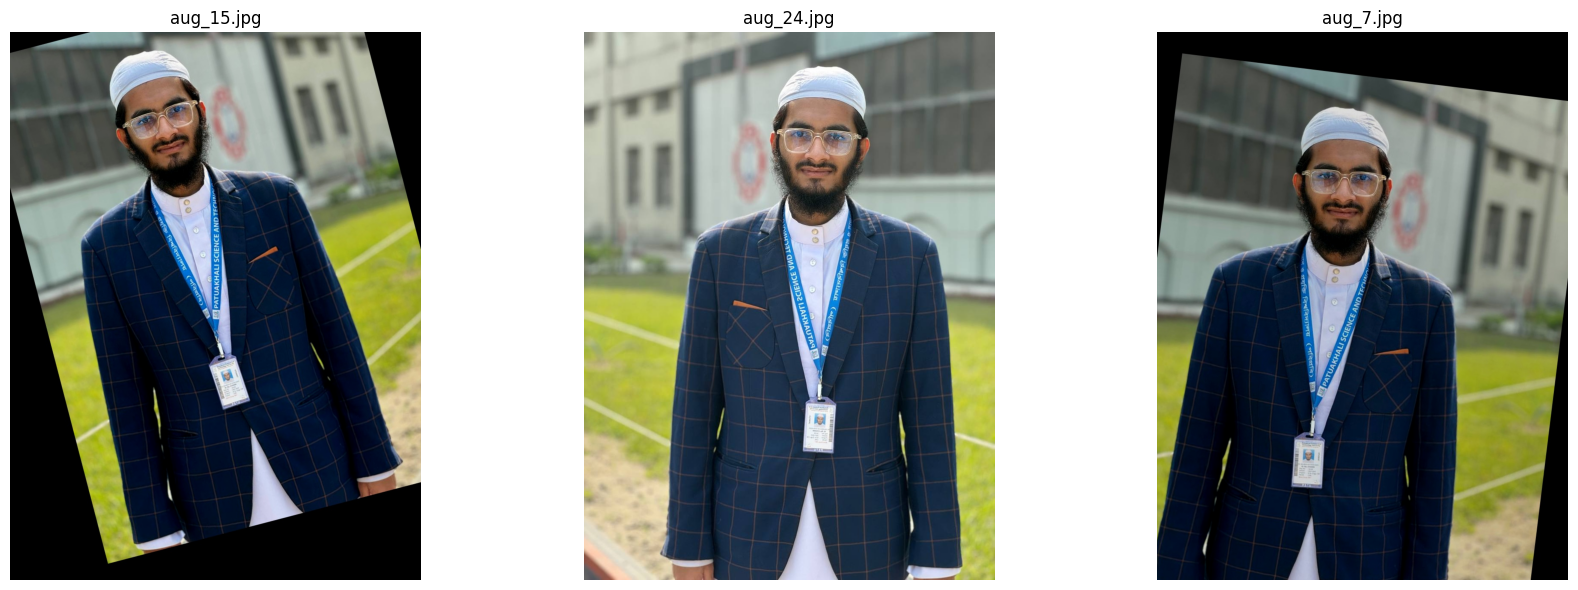

In [7]:
import os
import cv2
import random
import matplotlib.pyplot as plt

# ১. পাথ সেট করুন
images_dir = "/content/Celebrity-Faces-Dataset-1/train/images"

# ২. শুধু অগমেন্টেড (যাদের নামের শুরুতে 'aug_' আছে) ছবিগুলোর তালিকা তৈরি করা
aug_images = [f for f in os.listdir(images_dir) if f.startswith("aug_")]

if len(aug_images) == 0:
    print("❌ ফোল্ডারে 'aug_' নামের কোনো ছবি পাওয়া যায়নি! মেইন ফোল্ডারের সাধারণ ছবি দিয়ে চেক করা হচ্ছে...")
    aug_images = os.listdir(images_dir)

# ৩. ৩টি ছবি র্যান্ডমলি সিলেক্ট করা দেখার জন্য
sample_images = random.sample(aug_images, min(3, len(aug_images)))

# প্লট বা গ্রিড তৈরি করা (১টি সারিতে ৩টি ছবি দেখাবে)
fig, axes = plt.subplots(1, len(sample_images), figsize=(18, 6))
if len(sample_images) == 1:
    axes = [axes]

for idx, img_name in enumerate(sample_images):
    # ছবি লোড করা
    img_path = os.path.join(images_dir, img_name)
    image = cv2.imread(img_path)

    # OpenCV-এর BGR কালারকে Matplotlib-এর RGB কালারে কনভার্ট করা (নাহলে ছবির রঙ নীলচে দেখাবে)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # কোলাব স্ক্রিনে ছবি শো করা (কোনো বাউন্ডিং বক্স আঁকা ছাড়া)
    axes[idx].imshow(image)
    axes[idx].set_title(img_name, fontsize=12)
    axes[idx].axis("off") # ছবির চারপাশের এক্সিস বা স্কেল হাইড করার জন্য

plt.tight_layout()
plt.show()

**For google drive run**

In [8]:
!yolo task=detect mode=train resume=True model=/content/drive/MyDrive/YOLO_Celebrity_Project/celebrity_run/weights/last.pt

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Celebrity-Faces-Dataset-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/YOLO_Celebrity_Project/celebrity_run/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=celebrity_run, nbs=64, nms=False

In [ ]:
!yolo task=detect mode=train data=/content/Celebrity-Faces-Dataset-1/data.yaml model=yolov8n.pt epochs=100 imgsz=640 project=/content/drive/MyDrive/YOLO_Celebrity_Project name=celebrity_run

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Celebrity-Faces-Dataset-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=celebrity_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

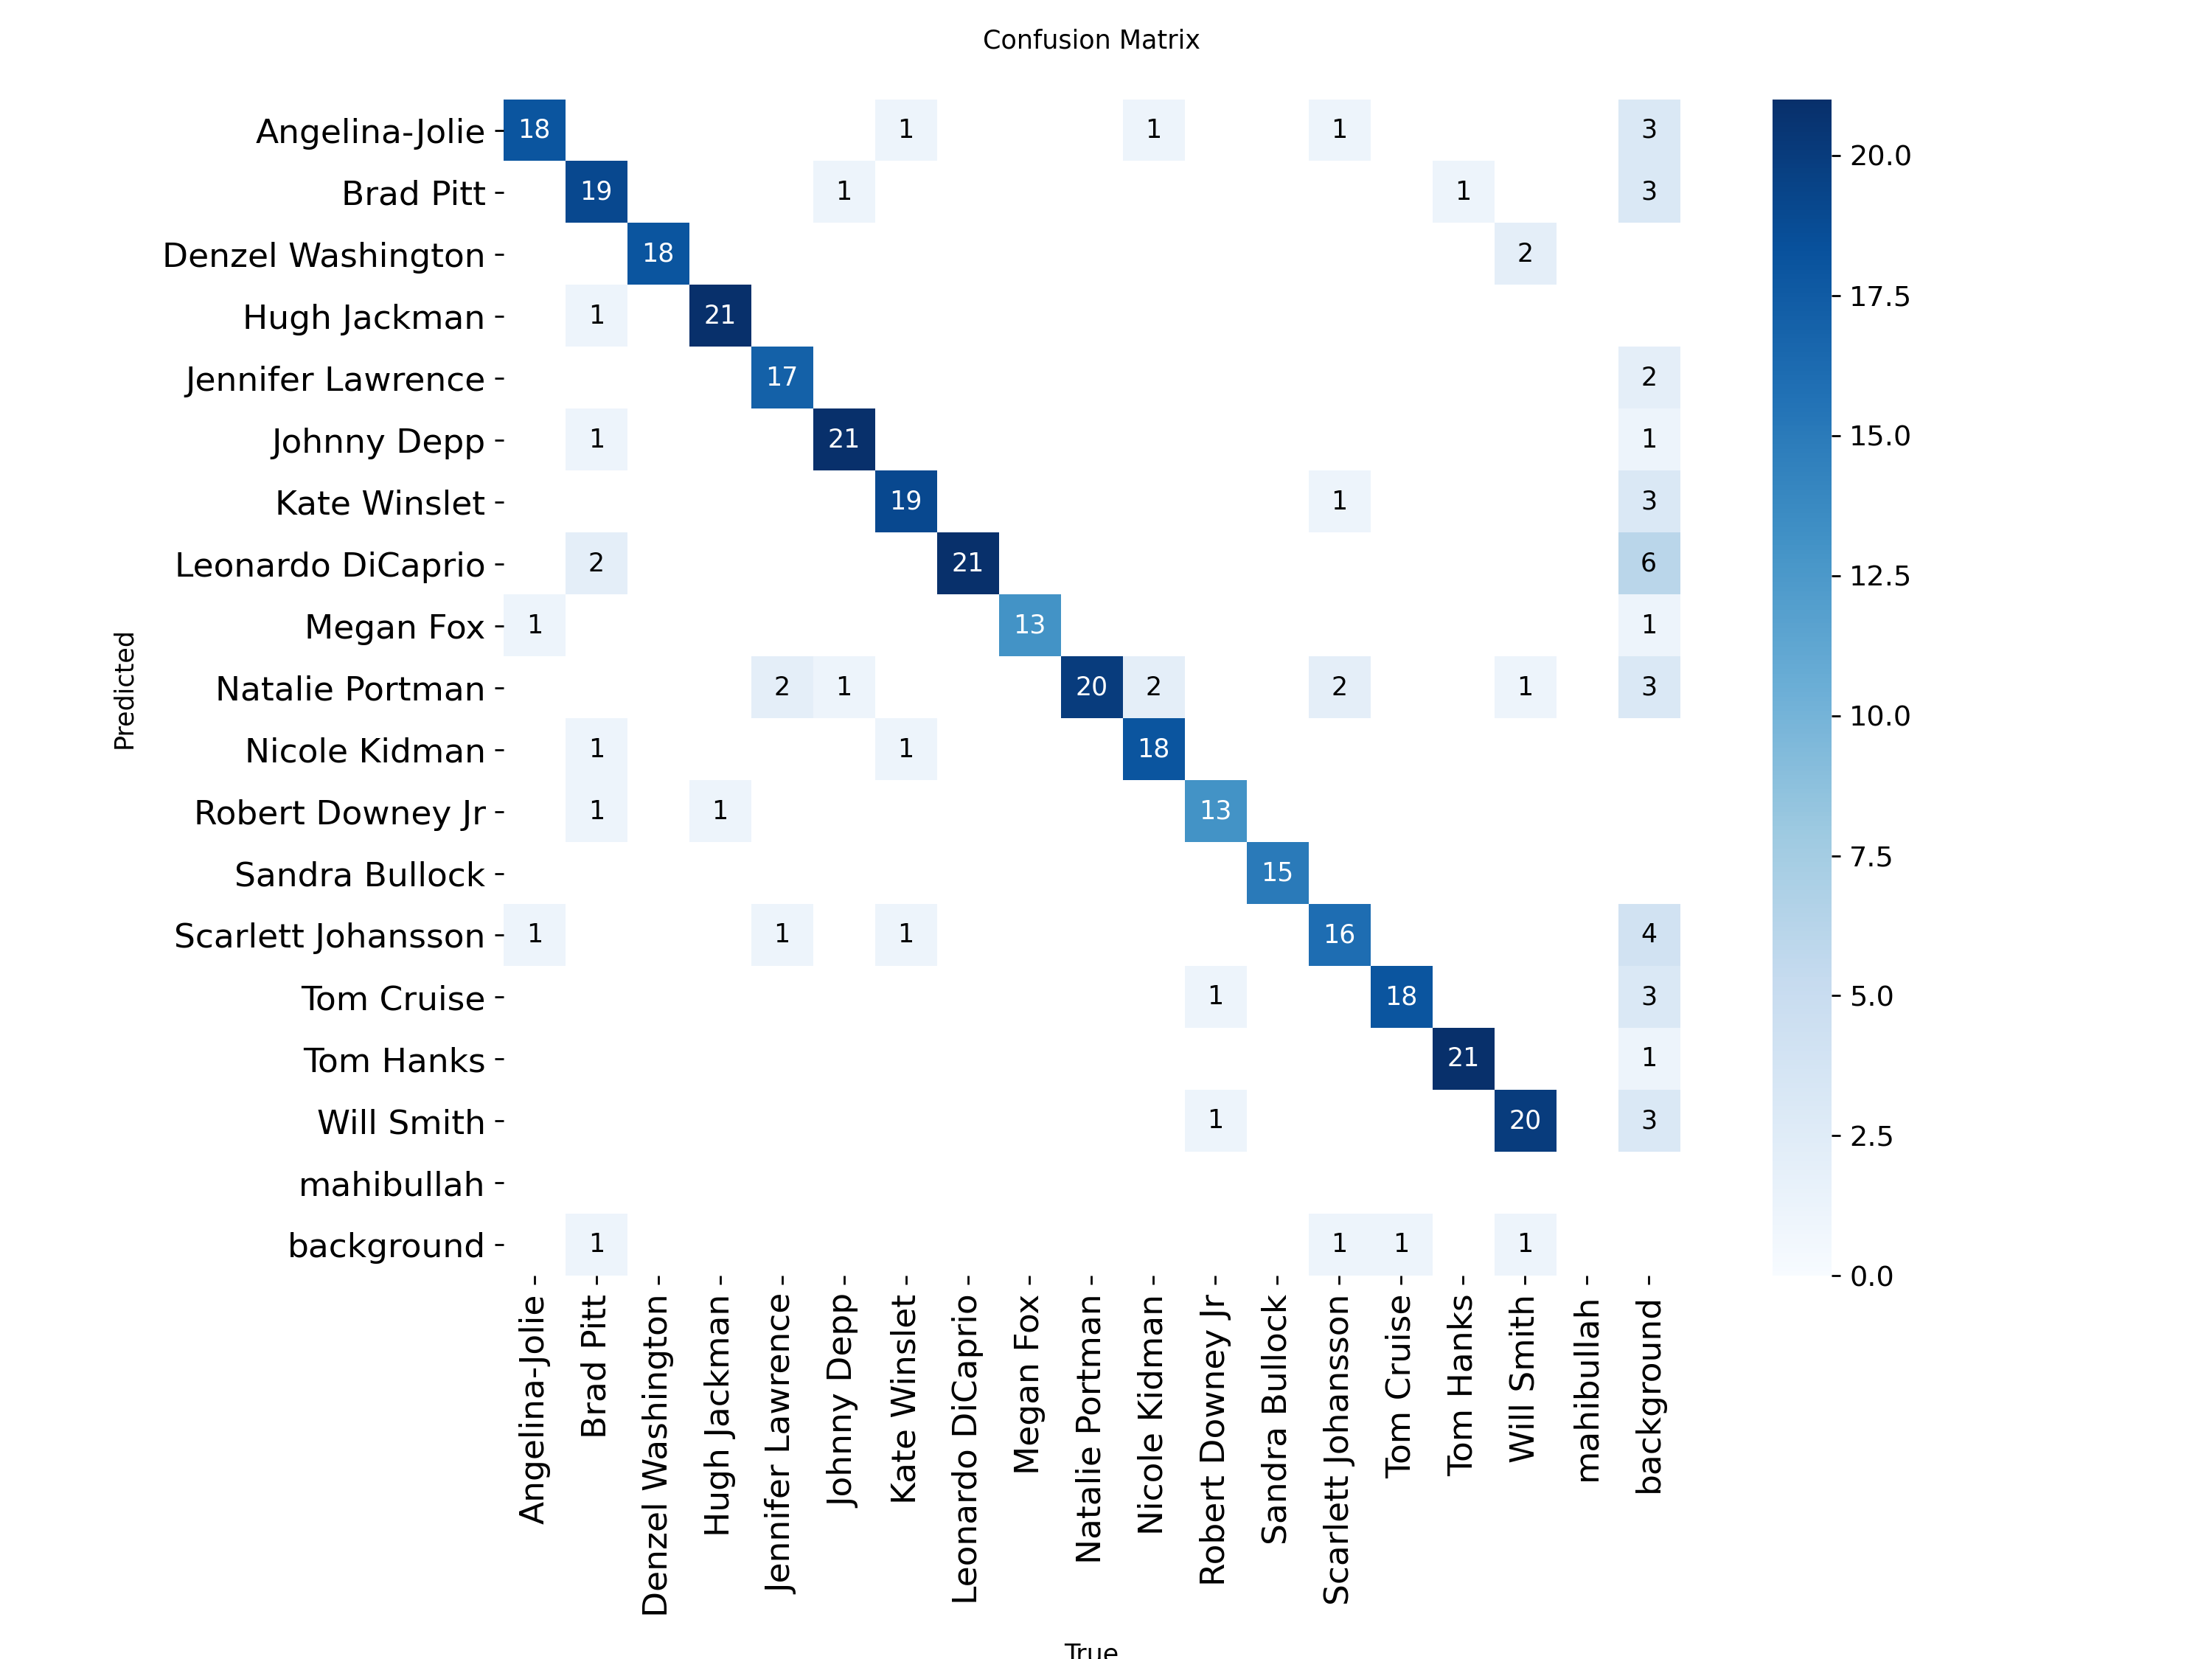

In [11]:
from IPython.display import Image
Image('/content/drive/MyDrive/YOLO_Celebrity_Project/celebrity_run/confusion_matrix.png', width=600)

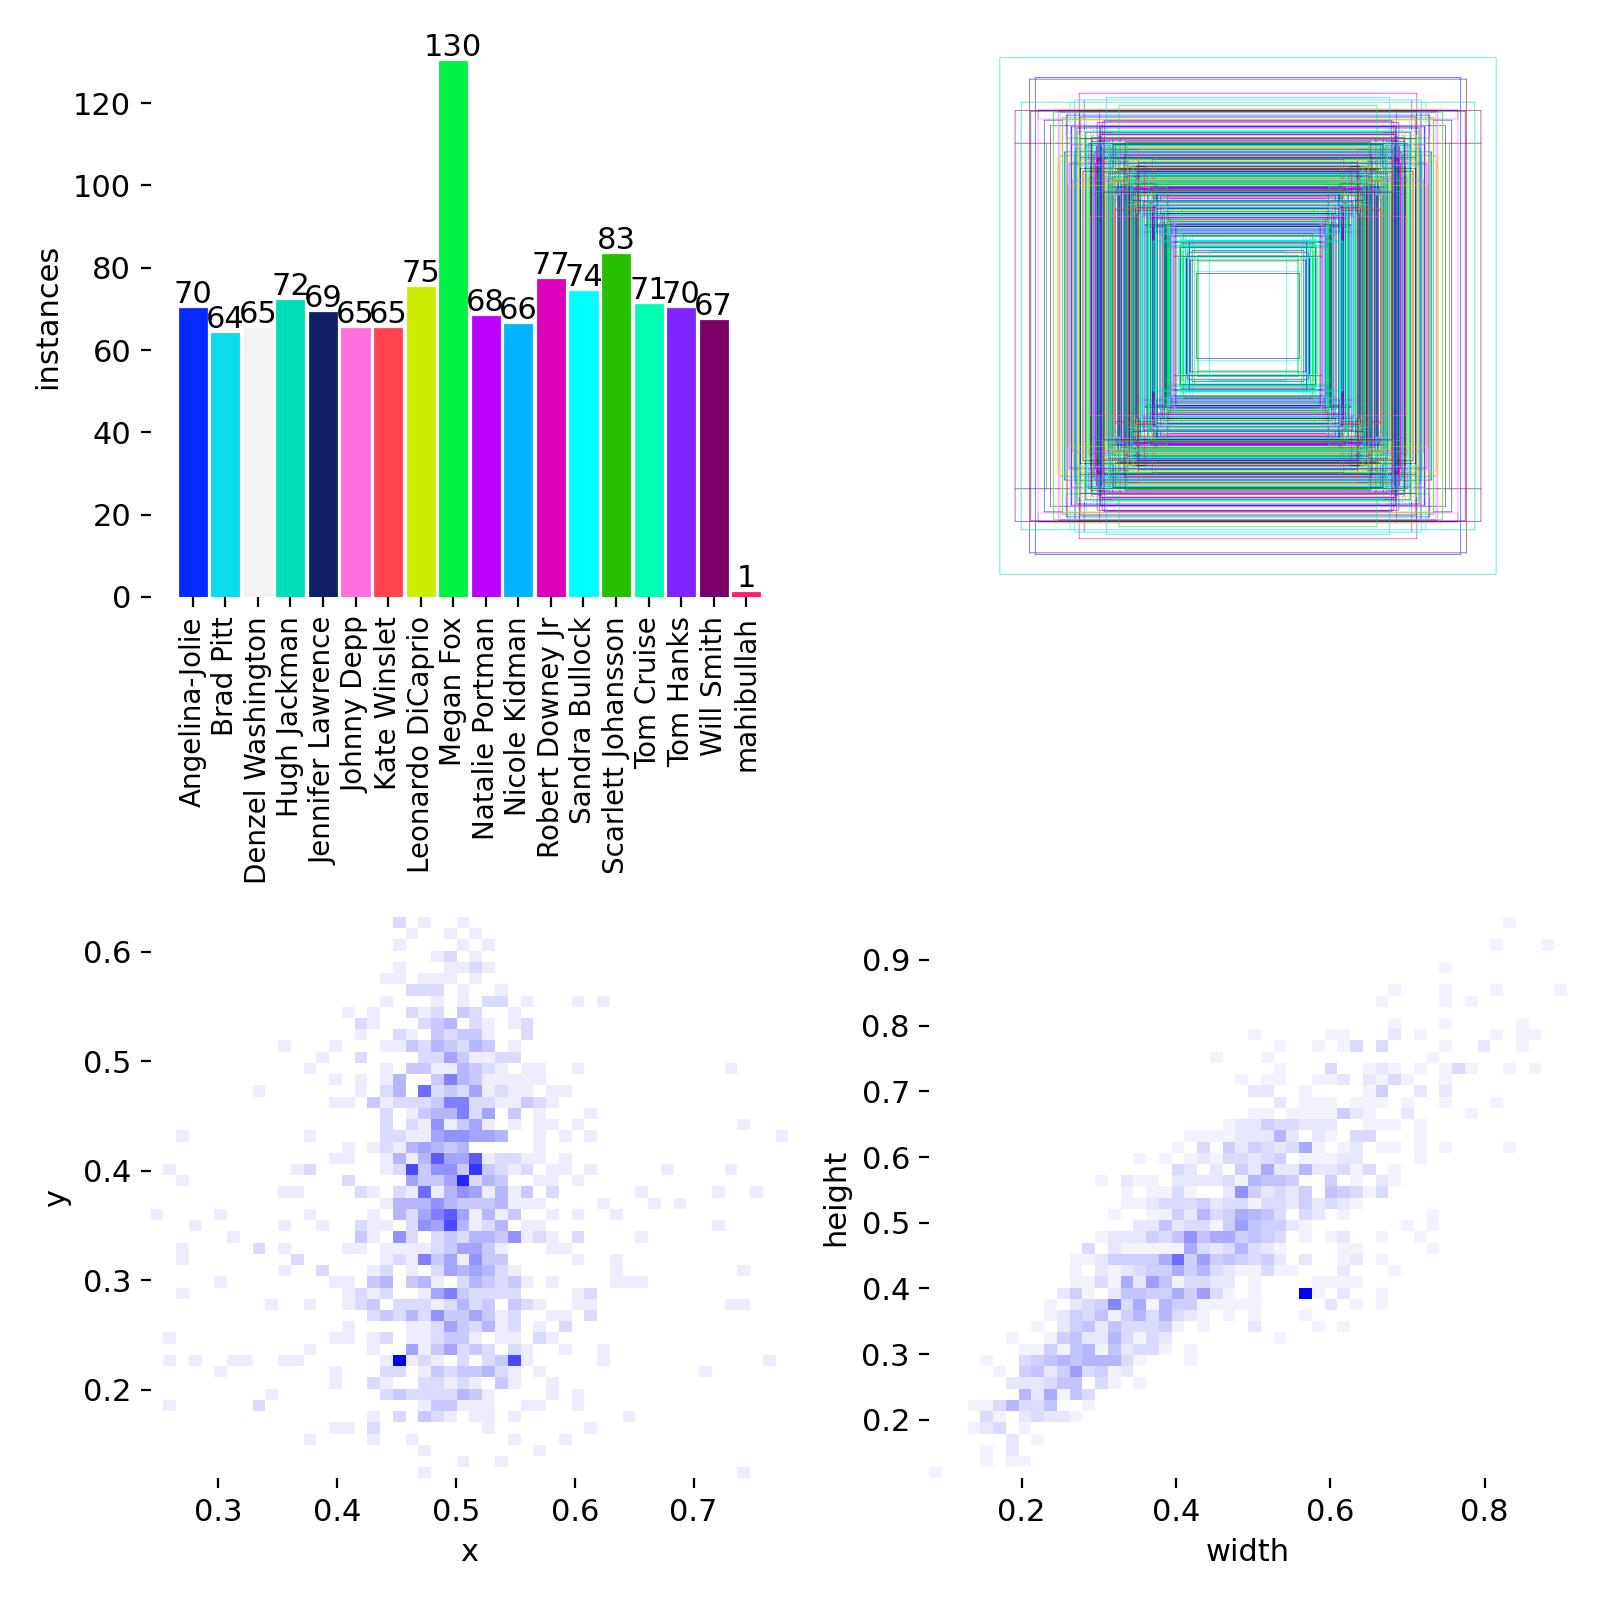

In [13]:
Image("/content/drive/MyDrive/YOLO_Celebrity_Project/celebrity_run/labels.jpg", width=600)

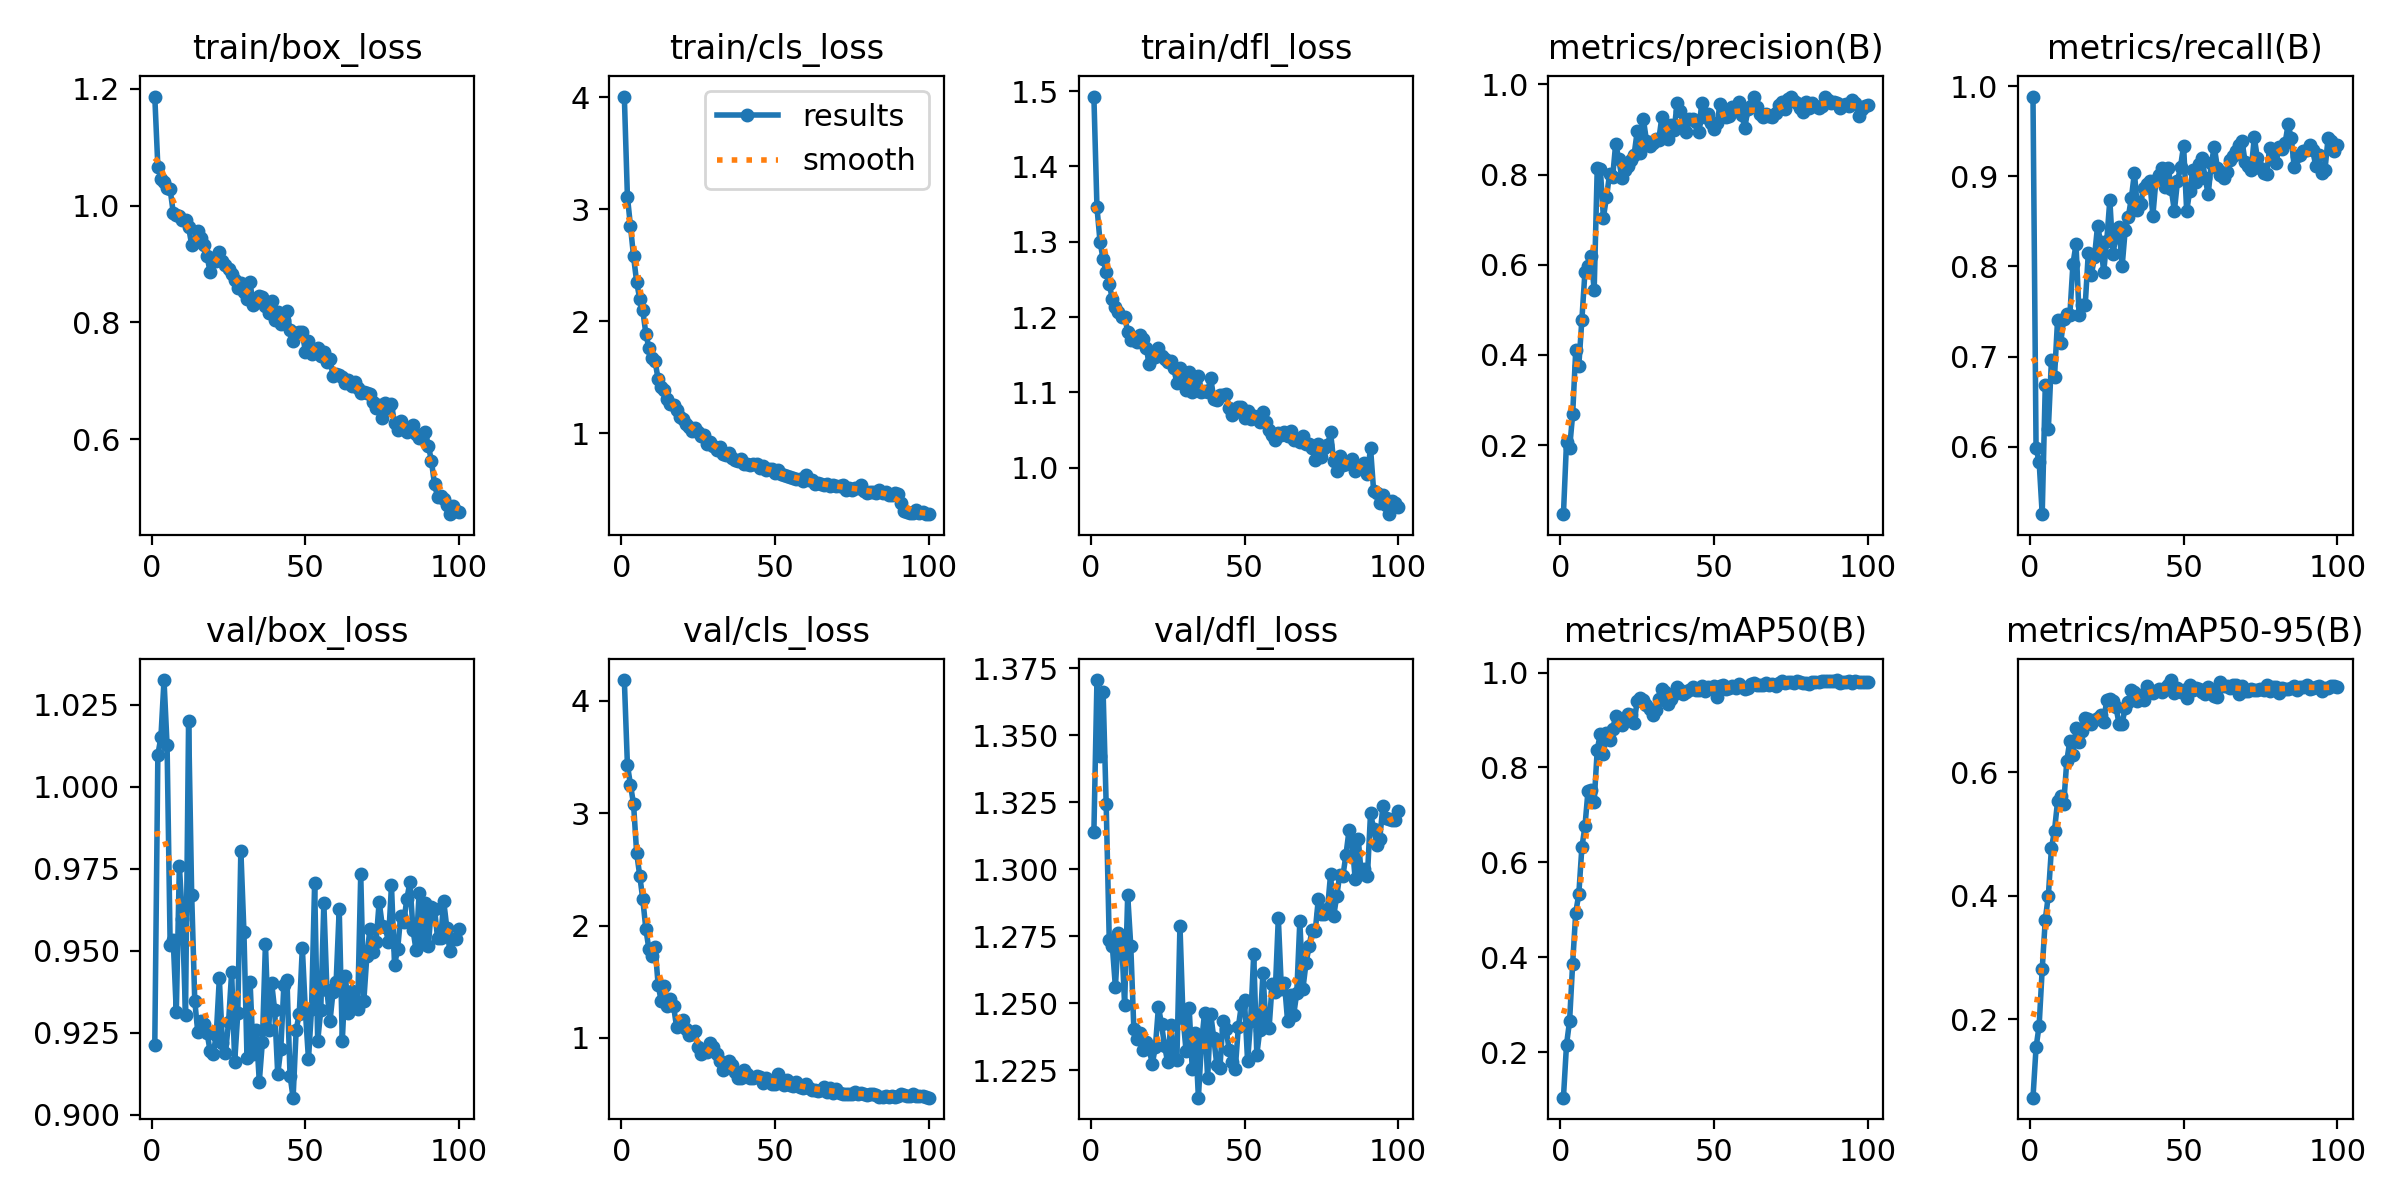

In [14]:
Image("/content/drive/MyDrive/YOLO_Celebrity_Project/celebrity_run/results.png", width=600)

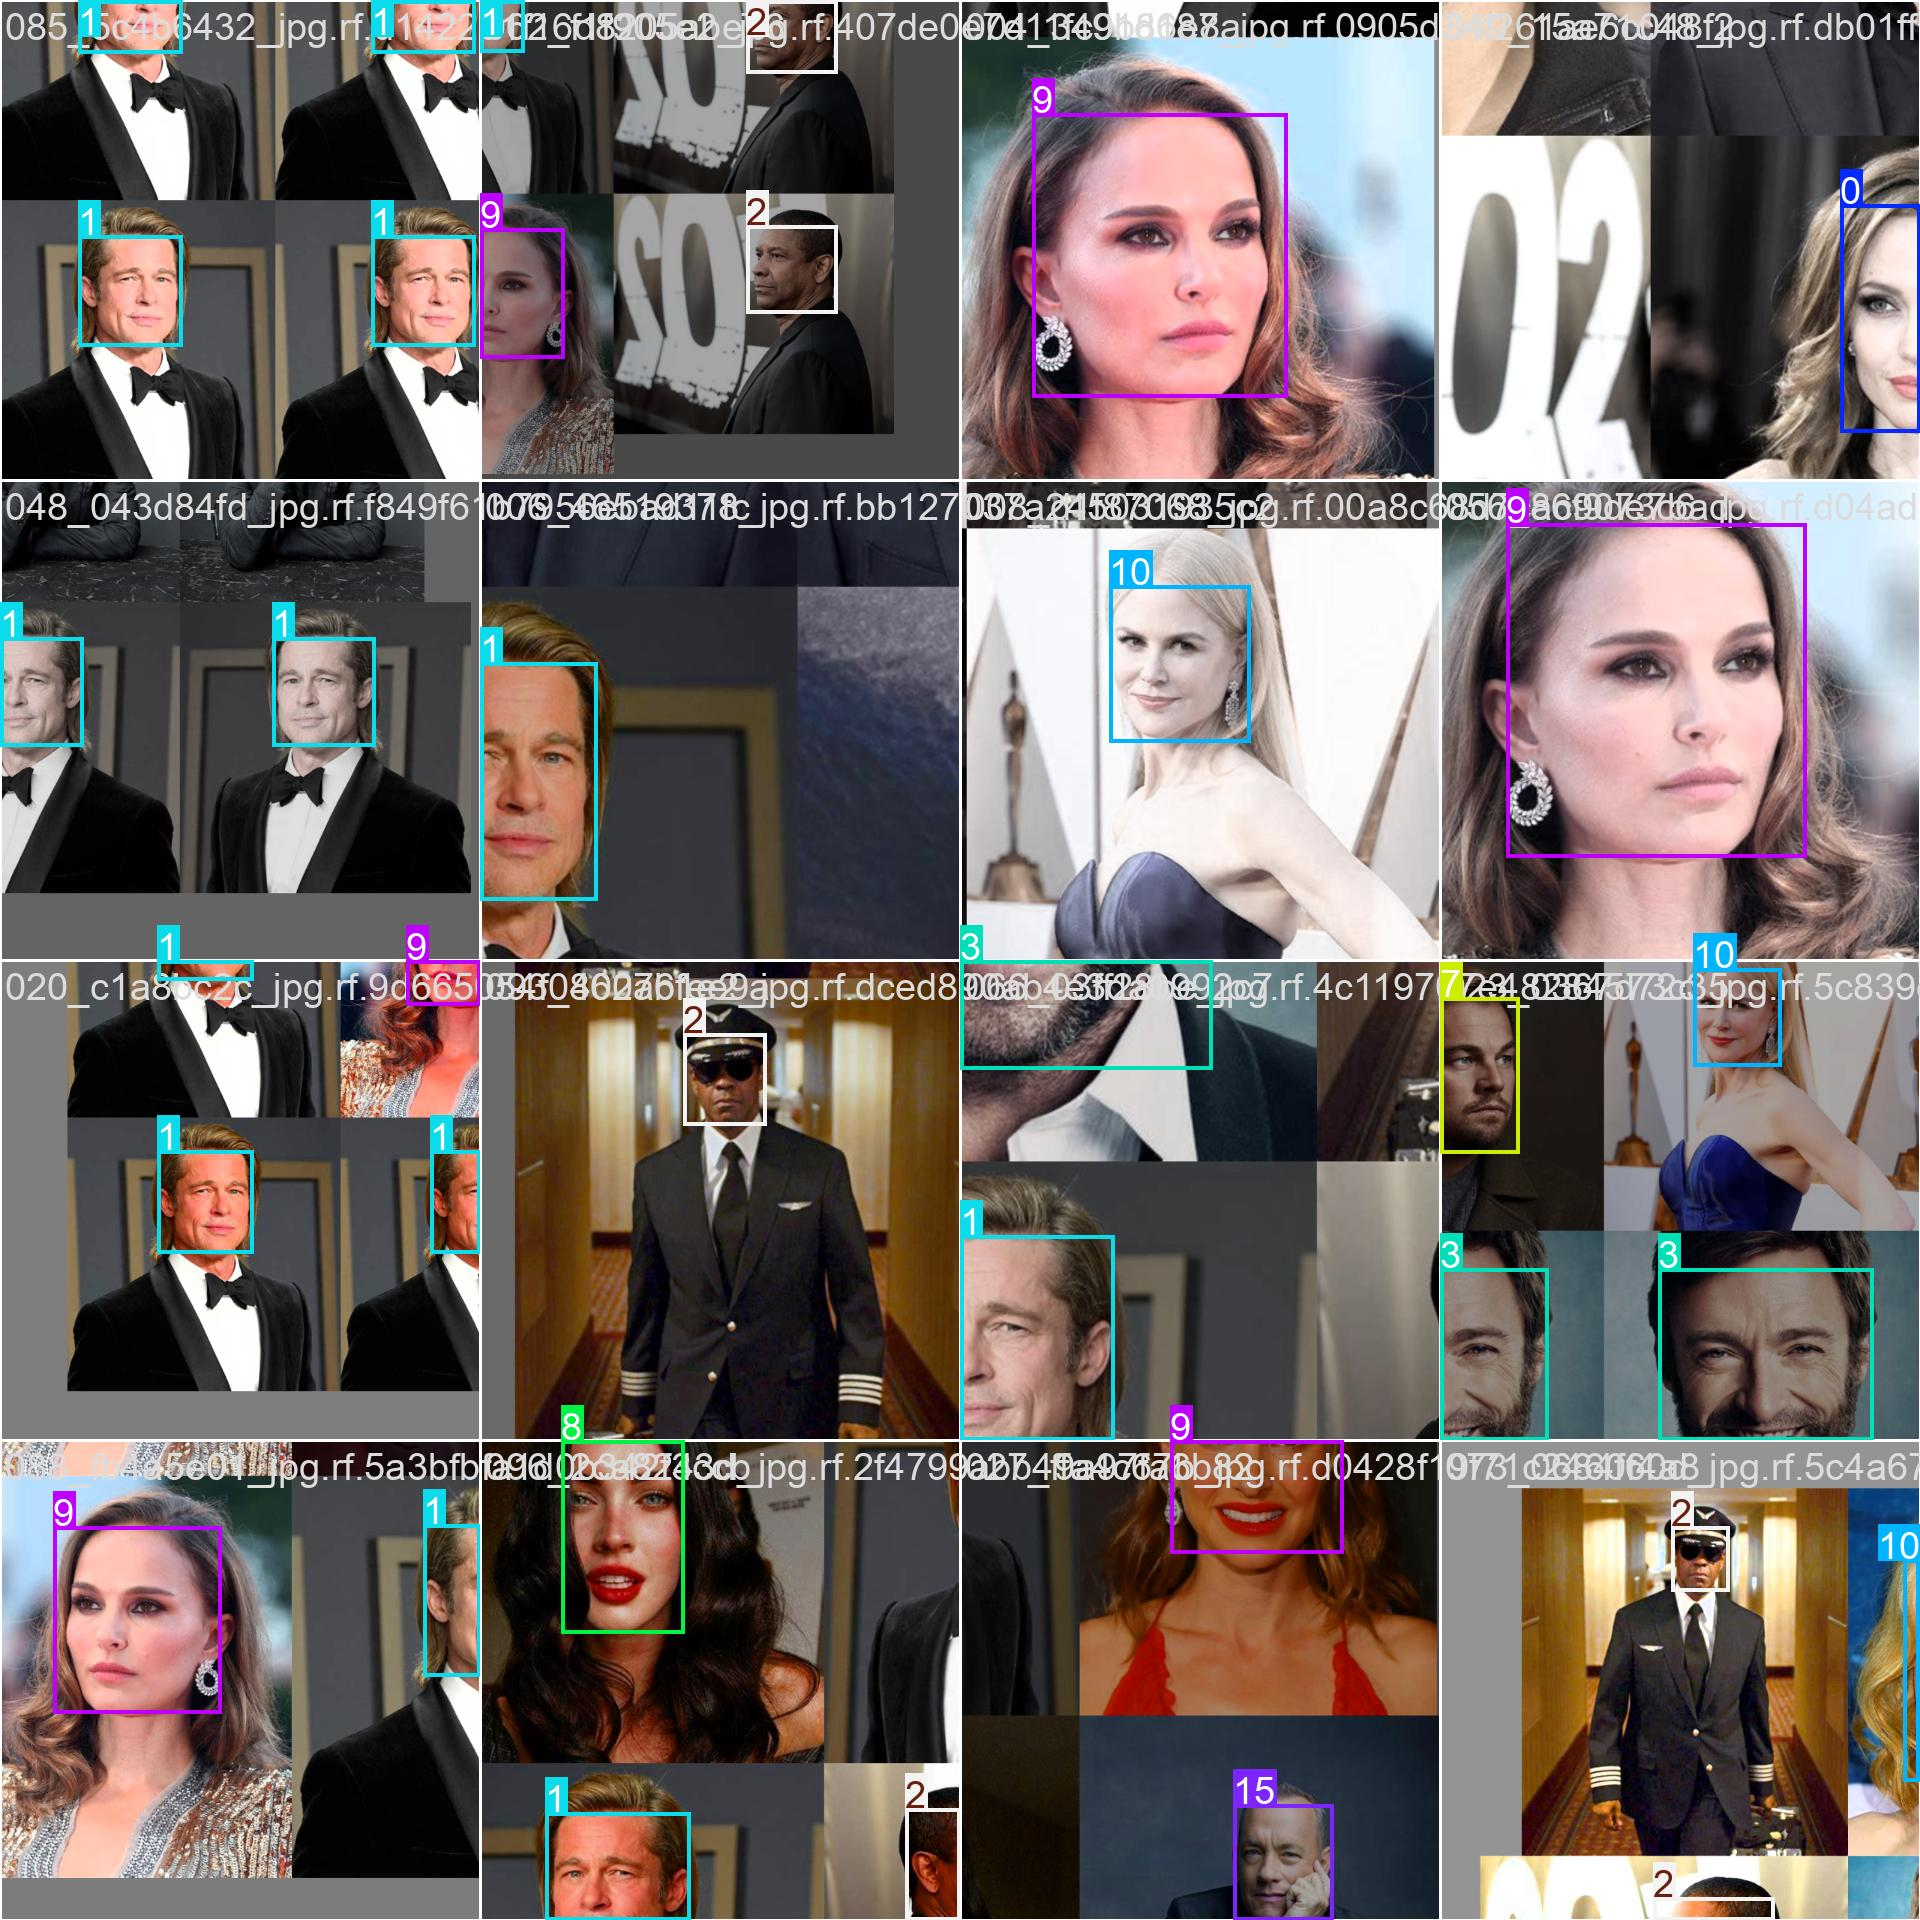

In [15]:
Image("/content/drive/MyDrive/YOLO_Celebrity_Project/celebrity_run/train_batch0.jpg", width=600)

In [17]:
val_pred_path = "/content/drive/MyDrive/YOLO_Celebrity_Project/celebrity_run/val_batch0_pred.jpg"

In [18]:
!yolo task=detect mode=val model="/content/drive/MyDrive/YOLO_Celebrity_Project/celebrity_run/weights/best.pt" data={dataset.location}/data.yaml

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 3,009,158 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1938.8±767.3 MB/s, size: 35.7 KB)
val: Scanning /content/Celebrity-Faces-Dataset-1/valid/labels.cache... 342 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 342/342 53.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 2.8s/it 1:02
                   all        342        342      0.955      0.886      0.971      0.748
        Angelina-Jolie         20         20      0.862      0.936      0.977      0.882
             Brad Pitt         26         26          1      0.724      0.933      0.795
     Denzel Washington         18         18      0.897          1      0.995      0.862
          Hugh Jackman         22         22          1      0.938      0.992      0.818
     Jennifer Lawrence         20        

In [19]:
!yolo task=detect mode=predict model="/content/drive/MyDrive/YOLO_Celebrity_Project/celebrity_run/weights/best.pt" conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 3,009,158 parameters, 0 gradients, 8.1 GFLOPs

image 1/171 /content/Celebrity-Faces-Dataset-1/test/images/001_504d320d_jpg.rf.a33ac89261675f19126095e7cb42de1e.jpg: 640x544 1 Nicole Kidman, 131.0ms
image 2/171 /content/Celebrity-Faces-Dataset-1/test/images/002_24fab375_jpg.rf.bbcb195c3b6df4eccab4f9075fd5f8a7.jpg: 640x544 1 Sandra Bullock, 127.4ms
image 3/171 /content/Celebrity-Faces-Dataset-1/test/images/002_36285f46_jpg.rf.e1d012811e0facc50f6a56da1b0aa82d.jpg: 640x544 1 Nicole Kidman, 122.1ms
image 4/171 /content/Celebrity-Faces-Dataset-1/test/images/002_533748b2_jpg.rf.c4ccbd11953e016623eddf1cdfd2387d.jpg: 640x640 1 Jennifer Lawrence, 149.6ms
image 5/171 /content/Celebrity-Faces-Dataset-1/test/images/002_f44b8d45_jpg.rf.d5420a7dcf5ae09b1ba8d2f2226a0d72.jpg: 640x640 1 Denzel Washington, 141.0ms
image 6/171 /content/Celebrity-Faces-Dataset-1/test/images/003_13b7bb9d_jpg.rf.cf24d618

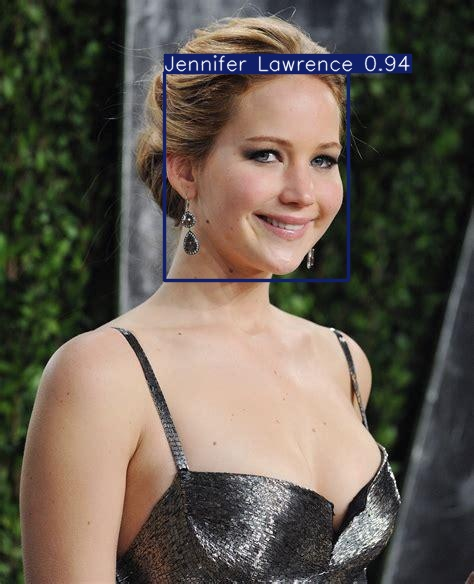

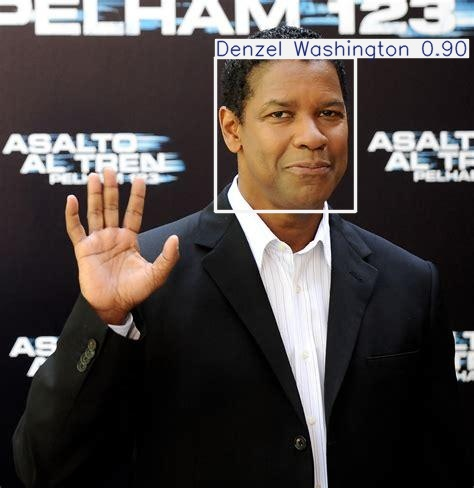

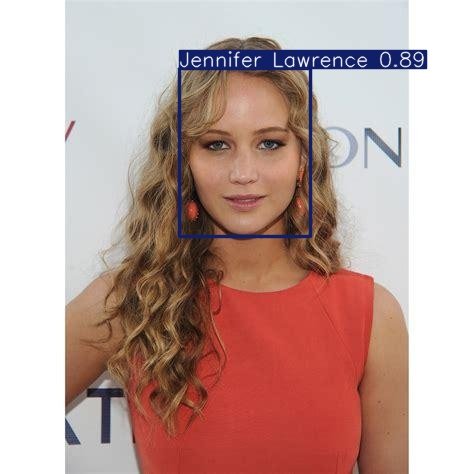

In [20]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob('/content/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[1:4]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [22]:
!yolo task=detect mode=predict model="/content/drive/MyDrive/YOLO_Celebrity_Project/celebrity_run/weights/best.pt" conf=0.25 source=/content/mahibullah.jpg save=True

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 3,009,158 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 /content/mahibullah.jpg: 640x480 1 Megan Fox, 124.5ms
Speed: 2.8ms preprocess, 124.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict-2
💡 Learn more at https://docs.ultralytics.com/modes/predict
